In [39]:
from dataclasses import dataclass
from typing import Dict, List, Tuple

from rich import box
from rich.console import Console, Group
from rich.panel import Panel
from rich.table import Table
from rich.text import Text


# =============================================================================
# Constants and unit conversions
# =============================================================================

C_M_S = 299_792_458.0
C_CM_S = C_M_S * 100.0


def nm_vac_to_THz(lambda_nm: float) -> float:
    return C_M_S / (lambda_nm * 1e-9) / 1e12


def THz_to_nm_vac(freq_THz: float) -> float:
    return C_M_S / (freq_THz * 1e12) * 1e9


def cm_to_THz(sigma_cm: float) -> float:
    return sigma_cm * C_CM_S / 1e12


def THz_to_cm(freq_THz: float) -> float:
    return freq_THz * 1e12 / C_CM_S


def MHz_to_THz(freq_MHz: float) -> float:
    return freq_MHz / 1e6


def THz_to_MHz(freq_THz: float) -> float:
    return freq_THz * 1e6



In [47]:
%matplotlib inline

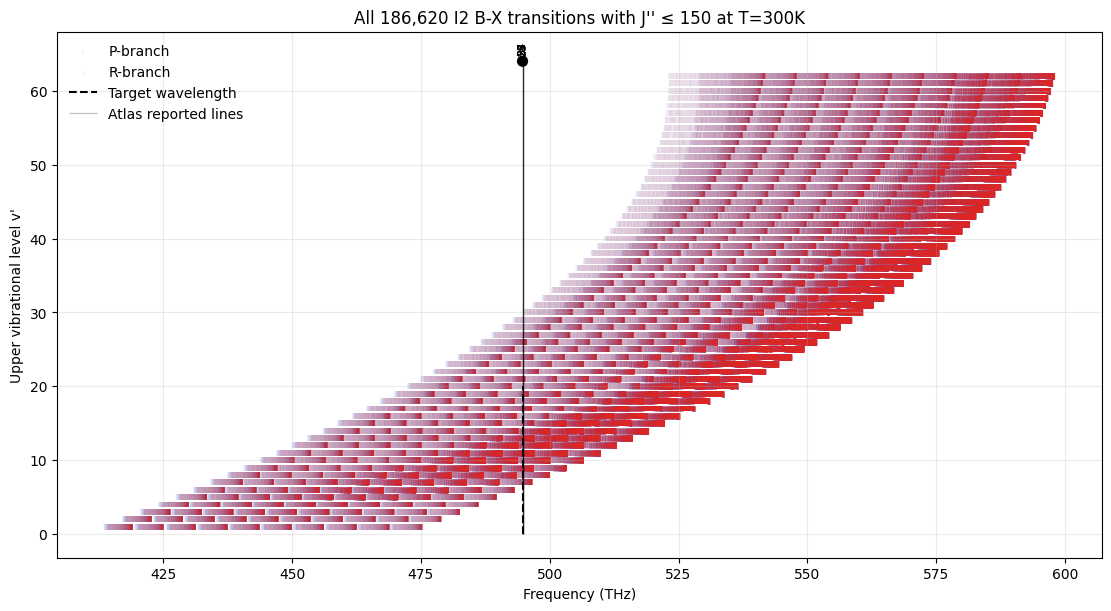

In [48]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


csv_candidates = [
    Path("iodine_bx_accurate_strengths_J150_T300.csv"),
    Path("PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv"),
    Path("../..") / "iodine_bx_accurate_strengths_J150_T300.csv",
    Path("../..") / "PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv",
]

for csv_path in csv_candidates:
    if csv_path.exists():
        break
else:
    raise FileNotFoundError("Could not find iodine_bx_accurate_strengths_J150_T300.csv")

transitions = pd.read_csv(csv_path)
transitions["strength_linewidth"] = 0.15 + 2.5 * np.sqrt(
    transitions["relative_strength_norm"].fillna(0.0).clip(lower=0.0)
)

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

COLOR_ACCURATE_P = "#2563EB"
COLOR_ACCURATE_R = "#DC2626"
branch_colors = {"P": COLOR_ACCURATE_P, "R": COLOR_ACCURATE_R}
for branch, group in transitions.groupby("branch", sort=True):
    ax.scatter(
        group["frequency_THz"],
        group["v_upper"],
        marker="|",
        s=18,
        linewidths=group["strength_linewidth"],
        alpha=0.5,
        color=branch_colors.get(branch, "tab:gray"),
        label=f"{branch}-branch",
        rasterized=True,
    )

ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Upper vibrational level v'")
ax.set_title(f"All {len(transitions):,} I2 B-X transitions with J'' ≤ 150 at T=300K")
ax.grid(alpha=0.25)
ax.vlines(nm_vac_to_THz(605.9770), 0, 20, color="black", linestyle="--", label="Target wavelength")

atlas_transitions_freq = [cm_to_THz(16501.9321), cm_to_THz(16502.0125), cm_to_THz(16502.4381), cm_to_THz(16502.5983), cm_to_THz(16502.8396), cm_to_THz(16502.9160)]
atlas_transitions_str = [23, 52, 27, 25, 34, 18]
atlas_strength_max = max(atlas_transitions_str)
atlas_y = transitions["v_upper"].max() + 2
atlas_marker_sizes = [35 + 165 * strength / atlas_strength_max for strength in atlas_transitions_str]

ax.vlines(atlas_transitions_freq, 0, atlas_y, color="black", alpha=0.25, linewidth=0.9, label="Atlas reported lines")
ax.scatter(
    atlas_transitions_freq,
    [atlas_y] * len(atlas_transitions_freq),
    s=atlas_marker_sizes,
    color="black",
    marker=".",
    zorder=5,
)
for freq_THz, strength in zip(atlas_transitions_freq, atlas_transitions_str):
    ax.text(freq_THz, atlas_y + 0.8, str(strength), ha="center", va="bottom", fontsize=8, rotation=90)

ax.set_ylim(top=atlas_y + 4)
ax.legend(frameon=False)

plt.show()

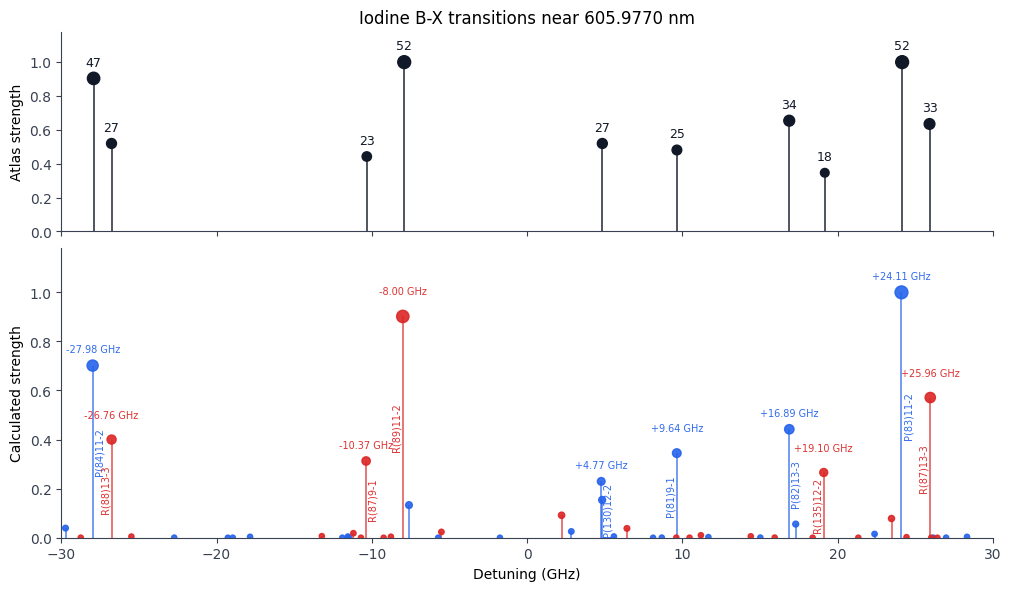

In [42]:
# Production plot: atlas reported lines vs accurate calculated strengths.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# Adjustable plot settings.
TARGET_NM_VAC = 605.9770
DETUNING_LIMIT_GHZ = 30.0
LABEL_STRENGTH_THRESHOLD = 0.20

# Adjustable colors, all hexadecimal.
COLOR_ATLAS = "#111827"
COLOR_ACCURATE_P = "#2563EB"
COLOR_ACCURATE_R = "#DC2626"
COLOR_TARGET = "#374151"
COLOR_GRID = "#D1D5DB"
COLOR_AXIS = "#374151"
COLOR_TEXT = "#111827"
COLOR_BACKGROUND = "#FFFFFF"


if "cm_to_THz" not in globals():
    C_CM_S = 299_792_458.0 * 100.0

    def cm_to_THz(sigma_cm: float) -> float:
        return sigma_cm * C_CM_S / 1e12


if "nm_vac_to_THz" not in globals():
    def nm_vac_to_THz(lambda_nm: float) -> float:
        return 299_792_458.0 / (lambda_nm * 1e-9) / 1e12


def find_existing_file(candidates, description):
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(f"Could not find {description}")


accurate_csv_path = find_existing_file(
    [
        Path("iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("../..") / "iodine_bx_accurate_strengths_J150_T300.csv",
        Path("../..") / "PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv",
    ],
    "iodine_bx_accurate_strengths_J150_T300.csv",
)

target_freq_THz = nm_vac_to_THz(TARGET_NM_VAC)

atlas_wavenumber_cm = [
    16501.0800,
    16501.3452,
    16501.3837,
    16501.9321,
    16502.0125,
    16502.4381,
    16502.5983,
    16502.8396,
    16502.9160,
    16503.0822,
    16503.1410,
    16503.5781,
]
atlas_reported_strength = [36, 47, 27, 23, 52, 27, 25, 34, 18, 52, 33, 21]
atlas_df = pd.DataFrame(
    {
        "frequency_THz": [cm_to_THz(sigma) for sigma in atlas_wavenumber_cm],
        "strength": atlas_reported_strength,
    }
)
atlas_df["detuning_GHz"] = (atlas_df["frequency_THz"] - target_freq_THz) * 1e3
atlas_df["relative_strength"] = atlas_df["strength"] / atlas_df["strength"].max()
atlas_window = atlas_df[atlas_df["detuning_GHz"].between(-DETUNING_LIMIT_GHZ, DETUNING_LIMIT_GHZ)].copy()

accurate_df = pd.read_csv(accurate_csv_path)
accurate_df["detuning_GHz"] = (accurate_df["frequency_THz"] - target_freq_THz) * 1e3
accurate_window = accurate_df[
    accurate_df["detuning_GHz"].between(-DETUNING_LIMIT_GHZ, DETUNING_LIMIT_GHZ)
].copy()

if accurate_window.empty:
    raise ValueError("No accurate calculated transitions found within +/-30 GHz of the target")

accurate_window["relative_strength_window"] = (
    accurate_window["relative_strength"] / accurate_window["relative_strength"].max()
)
accurate_window["transition_label"] = accurate_window.apply(
    lambda row: f"{row['branch']}({int(row['J_lower'])}){int(row['v_upper'])}-{int(row['v_lower'])}",
    axis=1,
)

fig, (ax_atlas, ax_calc) = plt.subplots(
    2,
    1,
    figsize=(10, 5.8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1.0, 1.45]},
)
fig.patch.set_facecolor(COLOR_BACKGROUND)

for axis in (ax_atlas, ax_calc):
    axis.set_facecolor(COLOR_BACKGROUND)
    #axis.axvline(0.0, color=COLOR_TARGET, linewidth=1.2, linestyle="--", alpha=0.85)
    axis.set_xlim(-DETUNING_LIMIT_GHZ, DETUNING_LIMIT_GHZ)
    axis.set_ylim(0.0, 1.18)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_color(COLOR_AXIS)
    axis.spines["bottom"].set_color(COLOR_AXIS)
    axis.tick_params(colors=COLOR_AXIS)

ax_atlas.vlines(
    atlas_window["detuning_GHz"],
    0.0,
    atlas_window["relative_strength"],
    color=COLOR_ATLAS,
    linewidth=1.15,
    alpha=0.9,
)
ax_atlas.scatter(
    atlas_window["detuning_GHz"],
    atlas_window["relative_strength"],
    s=14 + 72 * atlas_window["relative_strength"],
    color=COLOR_ATLAS,
    zorder=3,
)
for row in atlas_window.itertuples(index=False):
    ax_atlas.text(
        row.detuning_GHz,
        row.relative_strength + 0.055,
        f"{int(row.strength)}",
        color=COLOR_TEXT,
        ha="center",
        va="bottom",
        fontsize=9,
    )

branch_colors = {"P": COLOR_ACCURATE_P, "R": COLOR_ACCURATE_R}
for branch, group in accurate_window.groupby("branch", sort=True):
    color = branch_colors.get(branch, COLOR_AXIS)
    ax_calc.vlines(
        group["detuning_GHz"],
        0.0,
        group["relative_strength_window"],
        color=color,
        linewidth=1.15,
        alpha=0.78,
        label=f"{branch}-branch",
    )
    ax_calc.scatter(
        group["detuning_GHz"],
        group["relative_strength_window"],
        s=14 + 72 * group["relative_strength_window"],
        color=color,
        alpha=0.9,
        zorder=3,
    )

labeled_transitions = accurate_window[
    accurate_window["relative_strength_window"] >= LABEL_STRENGTH_THRESHOLD
].sort_values("detuning_GHz")
for i, row in enumerate(labeled_transitions.itertuples(index=False)):
    color = branch_colors.get(row.branch, COLOR_AXIS)
    x_offset = 0.42 if i % 2 == 0 else -0.42
    ax_calc.text(
        row.detuning_GHz + x_offset,
        row.relative_strength_window * 0.5,
        row.transition_label,
        rotation=90,
        color=color,
        ha="center",
        va="center",
        fontsize=7,
        alpha=0.95,
    )
    ax_calc.text(
        row.detuning_GHz,
        min(row.relative_strength_window + 0.045 + 0.035 * (i % 2), 1.14),
        f"{row.detuning_GHz:+.2f} GHz",
        color=color,
        ha="center",
        va="bottom",
        fontsize=7,
        alpha=0.95,
    )

ax_atlas.set_ylabel("Atlas strength")
ax_calc.set_ylabel("Calculated strength")
ax_calc.set_xlabel(f"Detuning (GHz)")
ax_atlas.set_title(f"Iodine B-X transitions near {TARGET_NM_VAC:.4f} nm")
#ax_calc.legend(frameon=False, loc="upper left", ncols=2)

plt.show()

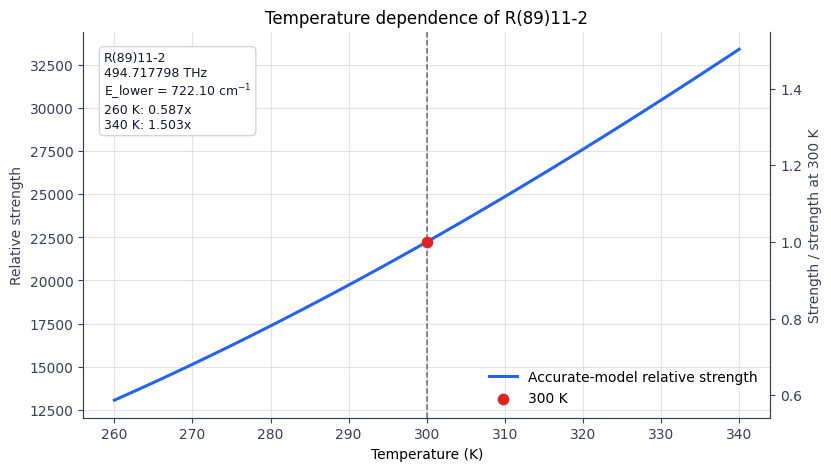

In [ ]:
# Temperature sweep for the accurate-model strength of R(89)11-2.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Adjustable settings.
T_CENTER_K = 300.0
T_HALF_RANGE_K = 40.0
N_TEMPERATURES = 161

TRANSITION_BRANCH = "R"
TRANSITION_J_LOWER = 89
TRANSITION_V_UPPER = 11
TRANSITION_V_LOWER = 2

# Adjustable colors, all hexadecimal.
COLOR_STRENGTH = "#2563EB"
COLOR_POINT = "#DC2626"
COLOR_REFERENCE = "#374151"
COLOR_GRID = "#D1D5DB"
COLOR_AXIS = "#374151"
COLOR_TEXT = "#111827"
COLOR_BACKGROUND = "#FFFFFF"

K_B_OVER_HC_CM = 0.695034800  # cm^-1 K^-1


def find_existing_file(candidates, description):
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(f"Could not find {description}")


accurate_csv_path = find_existing_file(
    [
        Path("iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("../..") / "PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv",
        Path("../..") / "iodine_bx_accurate_strengths_J150_T300.csv",
    ],
    "iodine_bx_accurate_strengths_J150_T300.csv",
)

accurate_df = pd.read_csv(accurate_csv_path)
transition_row = accurate_df[
    (accurate_df["branch"] == TRANSITION_BRANCH)
    & (accurate_df["J_lower"] == TRANSITION_J_LOWER)
    & (accurate_df["v_upper"] == TRANSITION_V_UPPER)
    & (accurate_df["v_lower"] == TRANSITION_V_LOWER)
]

if transition_row.empty:
    raise ValueError("Could not find the requested transition in the accurate-strength CSV")
if len(transition_row) > 1:
    raise ValueError("Found more than one matching transition; please tighten the selector")

transition = transition_row.iloc[0]
transition_label = (
    f"{transition['branch']}({int(transition['J_lower'])})"
    f"{int(transition['v_upper'])}-{int(transition['v_lower'])}"
)

temperatures_K = np.linspace(
    T_CENTER_K - T_HALF_RANGE_K,
    T_CENTER_K + T_HALF_RANGE_K,
    N_TEMPERATURES,
)

# The accurate-strength CSV convention is:
# relative_strength = constant_factors * exp(-E_lower / kT).
# Keep the non-thermal factors from the CSV and sweep only the Boltzmann factor.
E_lower_cm = float(transition["E_lower_cm-1"])
strength_without_boltzmann = float(transition["relative_strength"]) / float(transition["boltzmann"])
boltzmann_vs_T = np.exp(-E_lower_cm / (K_B_OVER_HC_CM * temperatures_K))
strength_vs_T = strength_without_boltzmann * boltzmann_vs_T

strength_at_center = float(
    strength_without_boltzmann
    * np.exp(-E_lower_cm / (K_B_OVER_HC_CM * T_CENTER_K))
)
strength_ratio_to_center = strength_vs_T / strength_at_center

fig, ax = plt.subplots(figsize=(8.2, 4.6), constrained_layout=True)
fig.patch.set_facecolor(COLOR_BACKGROUND)
ax.set_facecolor(COLOR_BACKGROUND)

ax.plot(
    temperatures_K,
    strength_vs_T,
    color=COLOR_STRENGTH,
    linewidth=2.2,
    label="Accurate-model relative strength",
)
ax.scatter(
    [T_CENTER_K],
    [strength_at_center],
    color=COLOR_POINT,
    s=55,
    zorder=3,
    label=f"{T_CENTER_K:.0f} K",
)
ax.axvline(T_CENTER_K, color=COLOR_REFERENCE, linestyle="--", linewidth=1.1, alpha=0.75)

ax_ratio = ax.twinx()
ax_ratio.plot(
    temperatures_K,
    strength_ratio_to_center,
    color=COLOR_STRENGTH,
    alpha=0.0,
)

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Relative strength")
ax_ratio.set_ylabel(f"Strength / strength at {T_CENTER_K:.0f} K")
ax.set_title(f"Temperature dependence of {transition_label}")
ax.grid(color=COLOR_GRID, linewidth=0.8, alpha=0.65)

for axis in (ax, ax_ratio):
    axis.tick_params(colors=COLOR_AXIS)
    axis.yaxis.label.set_color(COLOR_AXIS)

for spine in ("top", "right", "bottom", "left"):
    ax.spines[spine].set_color(COLOR_AXIS)
    ax_ratio.spines[spine].set_color(COLOR_AXIS)
ax.spines["top"].set_visible(False)
ax_ratio.spines["top"].set_visible(False)

summary_text = (
    f"{transition_label}\n"
    f"{float(transition['frequency_THz']):.6f} THz\n"
    f"E_lower = {E_lower_cm:.2f} cm$^{{-1}}$\n"
    f"{T_CENTER_K - T_HALF_RANGE_K:.0f} K: {strength_ratio_to_center[0]:.3f}x\n"
    f"{T_CENTER_K + T_HALF_RANGE_K:.0f} K: {strength_ratio_to_center[-1]:.3f}x"
)
ax.text(
    0.03,
    0.95,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    color=COLOR_TEXT,
    fontsize=9,
    bbox={"facecolor": COLOR_BACKGROUND, "edgecolor": COLOR_GRID, "boxstyle": "round,pad=0.35"},
)
ax.legend(frameon=False, loc="lower right")

plt.show()